In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with open("/kaggle/input/results/textcnn_optuna_best_params.json", "r") as f:
    best_params = json.load(f)

RANDOM_SEED = 42
N_FOLDS = 5
BATCH_SIZE = best_params['best_params']["batch_size"]
MAX_LENGTH = 256
EMBEDDING_DIM = 200
N_FILTERS = 128
FILTER_SIZES = [3, 4, 5]
HIDDEN_DIM = best_params['best_params']["hidden_dim"]
DROPOUT = best_params['best_params']["dropout"]
LEARNING_RATE = best_params['best_params']["learning_rate"]
WEIGHT_DECAY = best_params['best_params']["weight_decay"]
NUM_EPOCHS = 15
PATIENCE = 3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## 1. Load Data

In [8]:
# Load train and test data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train set: {len(train_df):,} reviews")
print(f"Test set: {len(test_df):,} reviews")
print("\nTrain sentiment distribution:")
print(train_df['voted_up'].value_counts(normalize=True))

Train set: 34,481 reviews
Test set: 6,086 reviews

Train sentiment distribution:
voted_up
True     0.500044
False    0.499956
Name: proportion, dtype: float64


In [9]:
# Prepare features and labels
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values

X_test = test_df['processed_text'].fillna('').values
y_test = test_df['voted_up'].astype(int).values

# Create stratification key for K-Fold
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

print(f"Features: {len(X_train):,} train, {len(X_test):,} test")
print(f"Labels: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Features: 34,481 train, 6,086 test
Labels: {0: 17239, 1: 17242}


## 2. Load FastText Embeddings

In [10]:
# Load pre-trained FastText model
print("Loading FastText model...")
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
print(f"FastText loaded: {ft_model.get_dimension()}-dimensional embeddings")
print(f"Vocabulary size: {len(ft_model.words):,}")

Loading FastText model...
FastText loaded: 200-dimensional embeddings
Vocabulary size: 32,313


## 3. Dataset and DataLoader

In [11]:
class SteamReviewDataset(Dataset):
    """Dataset for Steam reviews with FastText embeddings."""
    
    def __init__(self, texts, labels, ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Tokenize and get embeddings
        tokens = text.split()[:self.max_length]
        
        # Get word embeddings
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        
        # Create mask for actual tokens (1 for real, 0 for padding)
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }


def create_dataloader(texts, labels, ft_model, batch_size, shuffle=True):
    """Create DataLoader with optimizations."""
    dataset = SteamReviewDataset(texts, labels, ft_model, MAX_LENGTH)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=True
    )

## 4. Model Architecture

In [12]:
class TextCNNClassifier(nn.Module):
    def __init__(self, embedding_dim=200, n_filters=128, filter_sizes=[3, 4, 5],
                 hidden_dim=128, dropout=0.3):
        super().__init__()
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, 
                      out_channels=n_filters,
                      kernel_size=fs) 
            for fs in filter_sizes
        ])

        fc_input_dim = n_filters * len(filter_sizes)

        self.classifier = nn.Sequential(
            nn.Linear(fc_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask):
        masked_embeddings = embeddings * mask.unsqueeze(-1)
        
        # Input to Conv1d must be [batch, channels, length]
        x = masked_embeddings.permute(0, 2, 1)
        
        conved = [F.relu(conv(x)) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        combined = torch.cat(pooled, dim=1)
        logits = self.classifier(combined)
        
        return logits

# Instantiate model with config
model = TextCNNClassifier(EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, HIDDEN_DIM, DROPOUT)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TextCNNClassifier(
  (convs): ModuleList(
    (0): Conv1d(200, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(200, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(200, 128, kernel_size=(5,), stride=(1,))
  )
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.28889376562465907, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 332,289
Trainable parameters: 332,289


## 5. Training Functions

In [13]:
def train_epoch(model, dataloader, optimizer, criterion, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast(device_type=device.type):
            logits = model(embeddings, mask).squeeze(-1)
            loss = criterion(logits, labels)
        
        # Mixed precision backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            with autocast(device_type=device.type):
                logits = model(embeddings, mask).squeeze(-1)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

## 6. K-Fold Cross-Validation

In [14]:
# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Store metrics for each fold
fold_metrics = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'best_epoch': []
}

print(f"Running {N_FOLDS}-Fold Cross-Validation")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
    print(f"\nFold {fold + 1}/{N_FOLDS}")
    
    # Split data
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    # Create dataloaders
    train_loader = create_dataloader(X_fold_train, y_fold_train, ft_model, BATCH_SIZE, shuffle=True)
    val_loader = create_dataloader(X_fold_val, y_fold_val, ft_model, BATCH_SIZE, shuffle=False)
    
    # Initialize model, optimizer, criterion, scaler
    model = TextCNNClassifier(EMBEDDING_DIM, N_FILTERS, FILTER_SIZES,
                              HIDDEN_DIM, DROPOUT).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    
    # Training loop with early stopping
    best_val_f1 = 0
    patience_counter = 0
    best_epoch = 0
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Val F1={val_f1:.4f}")
        
        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_metrics = (val_acc, val_prec, val_rec, val_f1)
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Store best metrics
    fold_metrics['fold'].append(fold + 1)
    fold_metrics['accuracy'].append(best_metrics[0])
    fold_metrics['precision'].append(best_metrics[1])
    fold_metrics['recall'].append(best_metrics[2])
    fold_metrics['f1'].append(best_metrics[3])
    fold_metrics['best_epoch'].append(best_epoch)
    
    print(f"Fold {fold + 1} Best: Accuracy={best_metrics[0]:.4f}, Precision={best_metrics[1]:.4f}, "
          f"Recall={best_metrics[2]:.4f}, F1={best_metrics[3]:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(fold_metrics)

Running 5-Fold Cross-Validation

Fold 1/5


Epoch 1: Train Loss=0.3766, Val Loss=0.3041, Val F1=0.8704


Epoch 2: Train Loss=0.2629, Val Loss=0.3501, Val F1=0.8327


Epoch 3: Train Loss=0.1929, Val Loss=0.3932, Val F1=0.8553


Epoch 4: Train Loss=0.0930, Val Loss=0.4111, Val F1=0.8750


...

Epoch 3: Train Loss=0.2038, Val Loss=0.3475, Val F1=0.8482


Epoch 4: Train Loss=0.1071, Val Loss=0.3788, Val F1=0.8787


Epoch 5: Train Loss=0.0532, Val Loss=0.5485, Val F1=0.8684


Epoch 6: Train Loss=0.0308, Val Loss=0.5625, Val F1=0.8731


Epoch 7: Train Loss=0.0134, Val Loss=0.6434, Val F1=0.8778
Early stopping at epoch 7
Fold 5 Best: Accuracy=0.8795, Precision=0.8840, Recall=0.8735, F1=0.8787


In [15]:
# Summary statistics
print("CROSS-VALIDATION RESULTS SUMMARY")
print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"{metric.capitalize():<12} {mean:>10.4f} {std:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

print(f"\nMacro F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

CROSS-VALIDATION RESULTS SUMMARY

Metric             Mean        Std        Min        Max
Accuracy         0.8799     0.0026     0.8763     0.8836
Precision        0.8833     0.0071     0.8723     0.8920
Recall           0.8758     0.0137     0.8651     0.8988
F1               0.8794     0.0037     0.8750     0.8853

Macro F1 Score: 0.8794 ± 0.0037


## 7. Final Evaluation on Test Set

In [16]:
# Train on full training set
print("Training final model on full training set...")

train_loader = create_dataloader(X_train, y_train, ft_model, BATCH_SIZE, shuffle=True)
test_loader = create_dataloader(X_test, y_test, ft_model, BATCH_SIZE, shuffle=False)

# Initialize model
final_model = TextCNNClassifier(EMBEDDING_DIM, N_FILTERS, FILTER_SIZES,
                                HIDDEN_DIM, DROPOUT).to(device)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

optimal_epochs = int(np.median(fold_metrics['best_epoch']))
print(f"Using {optimal_epochs} epochs for final training (median of CV best epochs: {fold_metrics['best_epoch']})")

# Train
for epoch in range(optimal_epochs):
    train_loss, train_acc = train_epoch(final_model, train_loader, optimizer, criterion, scaler, device)
    print(f"Epoch {epoch+1}/{optimal_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")

Training final model on full training set...
Using 4 epochs for final training (median of CV best epochs: [4, 4, 5, 3, 4])


Epoch 1/4: Train Loss=0.3681, Train Acc=0.8368


Epoch 2/4: Train Loss=0.2590, Train Acc=0.8954


Epoch 3/4: Train Loss=0.2017, Train Acc=0.9219


Epoch 4/4: Train Loss=0.1474, Train Acc=0.9456


In [17]:
# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall, test_f1, y_test_pred, y_test_true = evaluate(
    final_model, test_loader, criterion, device
)

print("\nTEST SET RESULTS")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")


TEST SET RESULTS
Accuracy:  0.8810
Precision: 0.8948
Recall:    0.8636
F1 Score:  0.8789


In [18]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88      3043
    Positive       0.89      0.86      0.88      3043

    accuracy                           0.88      6086
   macro avg       0.88      0.88      0.88      6086
weighted avg       0.88      0.88      0.88      6086



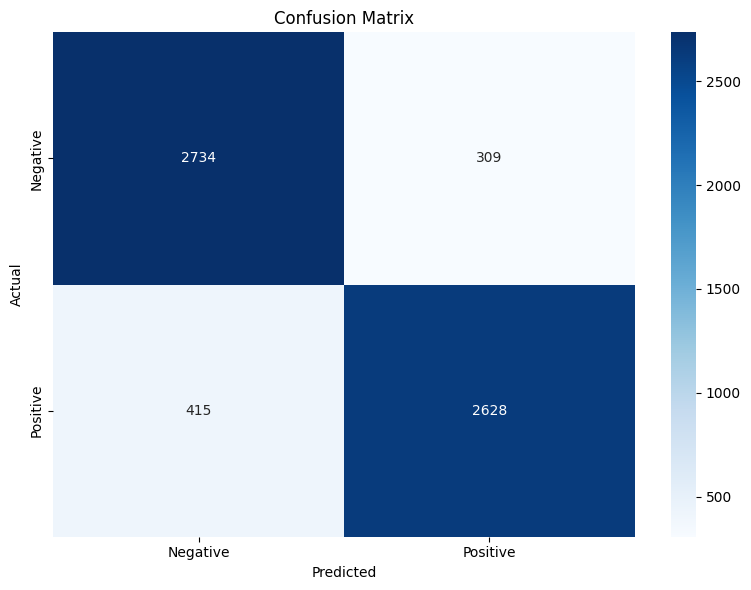


True Negatives:  2,734
False Positives: 309
False Negatives: 415
True Positives:  2,628


In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

## 8. Performance by Genre

In [20]:
# Analyze performance by genre
test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_test_pred
test_df_copy['correct'] = (test_df_copy['voted_up'].astype(int) == test_df_copy['predicted'])

genre_performance = test_df_copy.groupby('primary_genre').agg({
    'correct': ['sum', 'count', 'mean']
}).round(4)
genre_performance.columns = ['correct', 'total', 'accuracy']
genre_performance = genre_performance.sort_values('accuracy', ascending=False)

print("PERFORMANCE BY GENRE")
print(genre_performance.to_string())

PERFORMANCE BY GENRE
                        correct  total  accuracy
primary_genre                                   
puzzle_matching             507    555    0.9135
anime                       306    337    0.9080
sports                      262    292    0.8973
rpg_action                  616    688    0.8953
casual                      558    626    0.8914
science_fiction             852    963    0.8847
hidden_object                97    111    0.8739
visual_novel                 68     78    0.8718
action_fps                  626    719    0.8707
horror                      251    289    0.8685
exploration_open_world      643    748    0.8596
survival                    576    680    0.8471


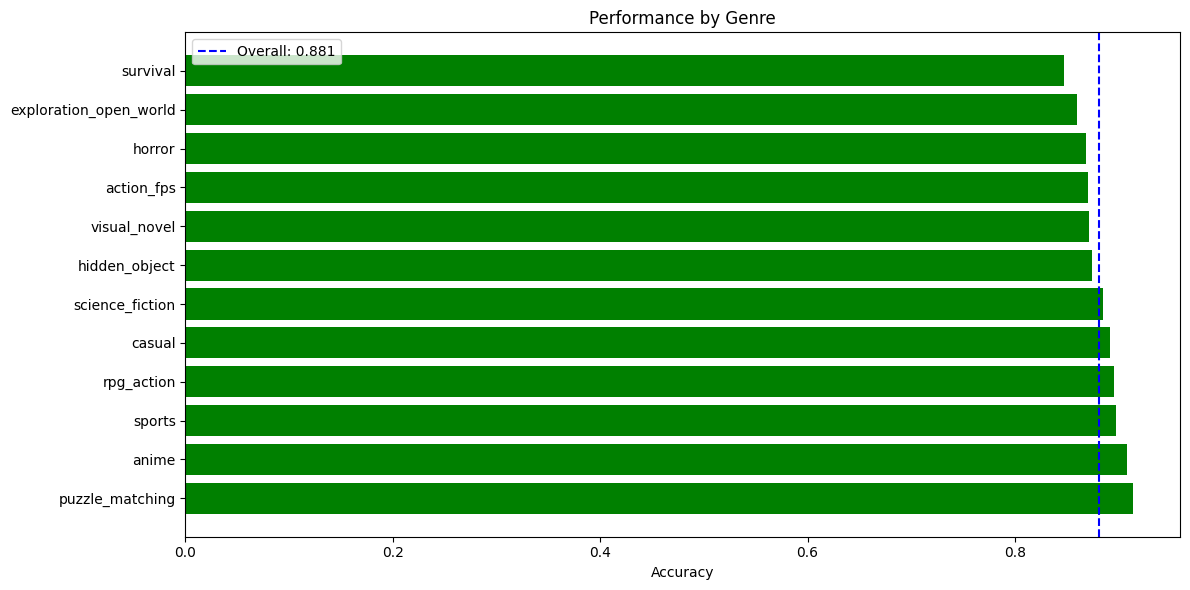

In [21]:
# Visualize genre performance
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0.75 else 'orange' if x >= 0.65 else 'red' 
          for x in genre_performance['accuracy']]
plt.barh(genre_performance.index, genre_performance['accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Performance by Genre')
plt.axvline(x=test_accuracy, color='blue', linestyle='--', label=f'Overall: {test_accuracy:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary & Save Results

In [22]:
# Summary
print("MODEL SUMMARY")
print("\nModel: TextCNN")
print(f"Embeddings: FastText {EMBEDDING_DIM}-dim (pre-trained on Steam reviews)")
print(f"\nCross-Validation ({N_FOLDS}-Fold):")
print(f"  F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print("\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

# Compare with baseline
baseline_f1 = 0.8558
print(f"\nComparison with Baseline:")
print(f"  Baseline F1:    {baseline_f1:.4f}")
print(f"  This Model F1:  {test_f1:.4f}")
print(f"  Difference:     {test_f1 - baseline_f1:+.4f}")

MODEL SUMMARY

Model: TextCNN
Embeddings: FastText 200-dim (pre-trained on Steam reviews)

Cross-Validation (5-Fold):
  F1 Score: 0.8794 ± 0.0037

Test Set Performance:
  Accuracy:  0.8810
  Precision: 0.8948
  Recall:    0.8636
  F1 Score:  0.8789

Comparison with Baseline:
  Baseline F1:    0.8558
  This Model F1:  0.8789
  Difference:     +0.0231


In [23]:
# Save results to JSON for comparison with other models
import json

results = {
    'model_name': 'TextCNN',
    'architecture': {
        'embedding_dim': EMBEDDING_DIM,
        'n_filters': N_FILTERS,
        'filter_sizes': FILTER_SIZES,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'max_length': MAX_LENGTH
    },
    'cross_validation': {
        'n_folds': N_FOLDS,
        'accuracy_mean': float(results_df['accuracy'].mean()),
        'accuracy_std': float(results_df['accuracy'].std()),
        'f1_mean': float(results_df['f1'].mean()),
        'f1_std': float(results_df['f1'].std()),
        'precision_mean': float(results_df['precision'].mean()),
        'recall_mean': float(results_df['recall'].mean())
    },
    'test_set': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1)
    }
}

# Save results
results_path = '/kaggle/working/results/text_cnn_results.json'
Path('/kaggle/working/results').mkdir(exist_ok=True)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to /kaggle/working/results/text_cnn_results.json


In [24]:
# Save model checkpoint
Path('/kaggle/working/models').mkdir(exist_ok=True)
model_path = '/kaggle/working/models/text_cnn.pt'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'n_filters': N_FILTERS,
        'filter_sizes': FILTER_SIZES,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT
    }
}, model_path)
print(f"Model saved to {model_path}")

Model saved to /kaggle/working/models/text_cnn.pt
